# Laboratorio 01 — Cotizaciones óptimas de un formador de mercado

**Microestructuras y Sistemas de Trading — ITESO**
Modelo de Copeland y Galai (1983)

Jesús Emmanuel Flores Cortés, 

---

Este notebook **solo analiza y grafica**. Toda la lógica del modelo vive en `src/model.py`
y el graficado en `src/plots.py`; aquí únicamente se importan y se interpretan resultados.

**Contenido:** secciones 3.1 (parámetros) y 3.2 (componentes del modelo y optimización).

In [1]:
import sys
from pathlib import Path

# El notebook vive en notebooks/, pero los imports son relativos a la raiz del repo.
raiz = Path.cwd()
while not (raiz / "src" / "model.py").exists():
    raiz = raiz.parent
sys.path.insert(0, str(raiz))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.model import (
    Params,
    prob_ejecucion,
    spread_choke,
    perdida_informados,
    perdida_informados_analitica,
    utilidad_esperada,
    medio_spread_monopolista,
    optimizar_cotizaciones,
)
from src.plots import figura_prob_ejecucion

from src.model import tabla_sensibilidad
from src.plots import (
    figura_inventario,
    figura_montecarlo,
    figura_pnl_acumulado,
    figura_sensibilidad,
)
from src.simulation import (
    deriva_inventario_teorica,
    regimenes,
    resumen_montecarlo,
    resumen_simulacion,
    simular_corridas,
    simular_trades,
)

N_TRADES = 10_000        # seccion 3.3: una corrida de detalle
N_CORRIDAS_MC = 1_000    # seccion 3.3: Monte Carlo
N_TRADES_MC = 1_000

pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Raiz del proyecto:", raiz)

Raiz del proyecto: C:\Users\jesus\Lab01_FinanzasCuantitativas_EquipoN


## 3.1 Parámetros del problema

Caso base fijo para todos los equipos. El valor verdadero del activo se modela como
$P \sim \text{Erlang}(K=60,\ \lambda=3)$, y la demanda no informada decae linealmente
con el medio spread $s$ medido desde $S_0$:

$$\pi_{LB}(s) = \pi_{LS}(s) = \max(0,\ \alpha - \beta s), \qquad \alpha = 0.50,\ \beta = 0.08$$

In [2]:
p = Params()
dist = p.distribucion()

tabla_params = pd.DataFrame(
    [
        ("Precio de referencia",   "S_0",          f"{p.S0:.2f}"),
        ("Distribucion del valor", "P",            f"Erlang(K={p.K}, lambda={p.lam:g})"),
        ("Prob. informado",        "pi_I",         f"{p.pi_i:.2f}"),
        ("Prob. liquidez",         "pi_L",         f"{p.pi_l:.2f}"),
        ("Demanda no informada",   "pi_LB, pi_LS", f"max(0, {p.alpha:.2f} - {p.beta:.2f}*s)"),
    ],
    columns=["Parametro", "Simbolo", "Valor"],
)
display(tabla_params)

print(f"Momentos de P:  E[P] = {dist.mean():.4f}   sd[P] = {dist.std():.4f}   "
      f"P(P < S_0) = {dist.cdf(p.S0):.4f}")

,Parametro,Simbolo,Valor
0,Precio de referencia,S_0,19.90
1,Distribucion del valor,P,"Erlang(K=60, lambda=3)"
2,Prob. informado,pi_I,0.40
3,Prob. liquidez,pi_L,0.60
4,Demanda no informada,"pi_LB, pi_LS","max(0, 0.50 - 0.08*s)"


Momentos de P:  E[P] = 20.0000   sd[P] = 2.5820   P(P < S_0) = 0.5017


Dos hechos que explican los resultados de más adelante:

1. $E[P] = 20.00 > S_0 = 19.90$. El precio de referencia está **por debajo** del valor
   esperado del activo, así que el lado de venta (Ask) enfrenta más selección adversa
   que el de compra.
2. $\sigma_P = 2.58$, un 13% del precio. La incertidumbre sobre el valor verdadero es
   grande, y eso empuja el spread hacia arriba.

## 3.2 Componentes del modelo

### a) Demanda no informada y punto de demanda nula

La probabilidad de ejecución se trunca en cero. Sin ese truncamiento, para
$s > \alpha/\beta$ la "probabilidad" sería negativa y la utilidad crecería sin cota
al ampliar el spread.

In [3]:
choke = spread_choke(p)
print(f"La probabilidad de ejecucion se anula en s = alpha/beta = {choke:.2f}")

muestra = pd.DataFrame({"s": [0.0, 1.0, 3.125, 5.0, 6.25, 8.0]})
muestra["prob_ejecucion"] = prob_ejecucion(muestra["s"].values, p)
display(muestra)

La probabilidad de ejecucion se anula en s = alpha/beta = 6.25


,s,prob_ejecucion
0,0.0000,0.5000
1,1.0000,0.4200
2,3.1250,0.2500
3,5.0000,0.1000
4,6.2500,0.0000
5,8.0000,0.0000


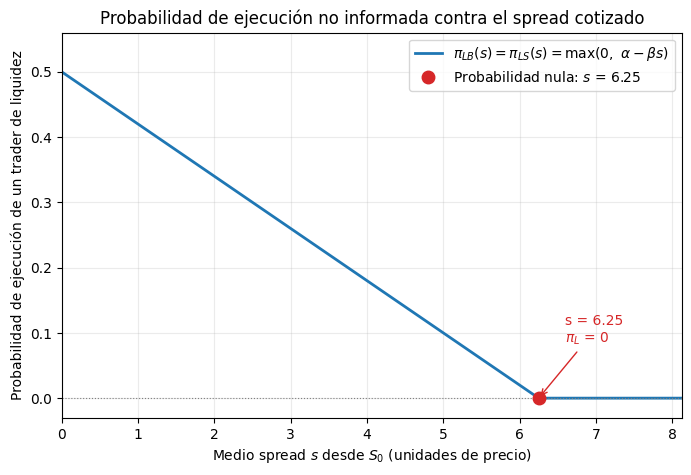

In [4]:
fig = figura_prob_ejecucion(p, ruta=None)
plt.show()

<!-- ### b) Pérdida esperada frente a informados

El informado compra al Ask solo si $P > A$, y vende al Bid solo si $P < B$. La pérdida
esperada del formador de mercado por lado es:

$$\int_A^{\infty} (P-A) f(P)\,dP \qquad\text{y}\qquad \int_0^{B} (B-P) f(P)\,dP$$

Ambas se calculan con `scipy.integrate.quad` (cuadratura adaptativa), no con sumas discretas.

**Validación.** Para $P \sim \text{Gamma}(K, 1/\lambda)$ estas integrales tienen forma cerrada:

$$\int_A^{\infty}(P-A)f(P)\,dP = \frac{K}{\lambda}\left(1-F_{K+1}(A)\right) - A\left(1-F_K(A)\right)$$

Comparamos la cuadratura contra esa expresión para confirmar que la implementación es correcta. -->

### b) Pérdida esperada frente a informados

El informado compra al **Ask** cuando \(P>A\) y vende al **Bid** cuando \(P<B\). Por eso, la pérdida esperada del formador de mercado en cada lado se calcula con estas integrales:

$$
\int_A^\infty (P-A)f(P)\,dP
\qquad \text{y} \qquad
\int_0^B (B-P)f(P)\,dP
$$

Para calcularlas usamos `scipy.integrate.quad`, que hace la integración de forma adaptativa en lugar de usar sumas discretas.

**Validación:** si \(P\sim\text{Gamma}(K,1/\lambda)\), también podemos obtener el resultado directamente con una fórmula cerrada. Comparamos ambos resultados para comprobar que la implementación de `quad` está funcionando correctamente.


In [5]:
filas = []
for A, B in [(19.90, 19.90), (21.00, 18.00), (23.50, 16.50), (25.00, 14.00)]:
    q_ask, q_bid = perdida_informados(A, B, p)
    a_ask, a_bid = perdida_informados_analitica(A, B, p)
    filas.append({
        "A": A, "B": B,
        "quad_ask": q_ask, "cerrada_ask": a_ask,
        "quad_bid": q_bid, "cerrada_bid": a_bid,
        "error_max": max(abs(q_ask - a_ask), abs(q_bid - a_bid)),
    })

validacion = pd.DataFrame(filas)
display(validacion)
print(f"Error maximo global: {validacion['error_max'].max():.2e}")

,A,B,quad_ask,cerrada_ask,quad_bid,cerrada_bid,error_max
0,19.9000,19.9000,1.0777,1.0777,0.9777,0.9777,0.0000
1,21.0000,18.0000,0.6208,0.6208,0.2976,0.2976,0.0000
2,23.5000,16.5000,0.1279,0.1279,0.0801,0.0801,0.0000
3,25.0000,14.0000,0.0400,0.0400,0.0032,0.0032,0.0000


Error maximo global: 1.91e-14


El error es del orden de $10^{-14}$: la cuadratura reproduce la forma cerrada hasta
precisión de máquina.

Nótese que en $A = B = S_0$ la pérdida del lado Ask (1.0777) supera a la del lado Bid
(0.9777) por exactamente $0.10 = E[P] - S_0$. Esa asimetría es la que después hace que
el Ask óptimo se aleje más de $S_0$ que el Bid.

### c) Utilidad esperada y optimización

$$\Pi(A,B) = \pi_L\left[\pi_{LB}(A-S_0)(A-S_0) + \pi_{LS}(S_0-B)(S_0-B)\right]
- \pi_I\left[\int_A^{\infty}(P-A)f(P)\,dP + \int_0^{B}(B-P)f(P)\,dP\right]$$

Se minimiza $-\Pi(A,B)$ con `scipy.optimize.minimize` (L-BFGS-B) sujeto a
$A \in [S_0, \infty)$ y $B \in (0, S_0]$.

In [6]:
res = optimizar_cotizaciones(p)

resumen = pd.DataFrame(
    [
        ("Bid optimo",                  res["bid"]),
        ("Ask optimo",                  res["ask"]),
        ("Spread",                      res["spread"]),
        ("Utilidad esperada por trade", res["utilidad"]),
    ],
    columns=["Concepto", "Valor"],
)
display(resumen.style.format({"Valor": "{:.2f}"}))

,Concepto,Valor
0,Bid optimo,16.45
1,Ask optimo,23.43
2,Spread,6.98
3,Utilidad esperada por trade,0.84


In [7]:
desglose = pd.DataFrame(
    [
        ("Ganancia esperada frente a liquidez", res["ganancia_liquidez"]),
        ("Perdida esperada lado Ask",          -p.pi_i * res["perdida_ask"]),
        ("Perdida esperada lado Bid",          -p.pi_i * res["perdida_bid"]),
        ("Utilidad neta por trade",             res["utilidad"]),
    ],
    columns=["Componente", "Aporte a Pi"],
)
display(desglose)

print(f"Medio spread Ask: {res['medio_spread_ask']:.4f}  ->  pi_LB = {res['prob_ejec_ask']:.4f}")
print(f"Medio spread Bid: {res['medio_spread_bid']:.4f}  ->  pi_LS = {res['prob_ejec_bid']:.4f}")

,Componente,Aporte a Pi
0,Ganancia esperada frente a liquidez,0.9247
1,Perdida esperada lado Ask,-0.0539
2,Perdida esperada lado Bid,-0.0305
3,Utilidad neta por trade,0.8403


Medio spread Ask: 3.5277  ->  pi_LB = 0.2178
Medio spread Bid: 3.4483  ->  pi_LS = 0.2241


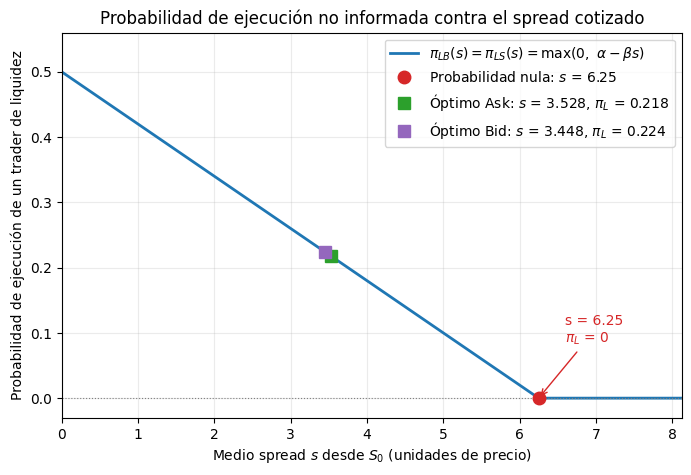

In [8]:
fig = figura_prob_ejecucion(p, resultado=res)
plt.show()

### d) Verificación de que el óptimo es global

La función objetivo tiene una **meseta plana en cero**: si ambos lados cotizan más allá
de $s = 6.25$ no hay ejecución, $\Pi \equiv 0$ y el gradiente también es cero, así que un
optimizador que arranque ahí reporta convergencia en un punto que no es óptimo. Por eso
`optimizar_cotizaciones` usa varios puntos de arranque.

Abajo se confirma el resultado con un barrido en malla, fijando un lado en su óptimo y
recorriendo el otro.

In [9]:
malla = np.linspace(0.01, choke * 1.2, 400)

util_ask = np.array([utilidad_esperada(p.S0 + s, res["bid"], p) for s in malla])
util_bid = np.array([utilidad_esperada(res["ask"], p.S0 - s, p) for s in malla])

print(f"Mejor s_ask en la malla: {malla[util_ask.argmax()]:.4f}   "
      f"(optimizador: {res['medio_spread_ask']:.4f})")
print(f"Mejor s_bid en la malla: {malla[util_bid.argmax()]:.4f}   "
      f"(optimizador: {res['medio_spread_bid']:.4f})")

Mejor s_ask en la malla: 3.5204   (optimizador: 3.5277)
Mejor s_bid en la malla: 3.4453   (optimizador: 3.4483)


### e) Caso $\pi_I = 0$ y el óptimo del monopolista

Sin traders informados la utilidad por lado se reduce a $\pi_L(\alpha - \beta s)s$, una
parábola cóncava cuyo máximo está donde $\alpha - 2\beta s = 0$:

$$s^{*} = \frac{\alpha}{2\beta} = \frac{0.50}{0.16} = 3.125$$

> **Discrepancia con el enunciado.** El PDF (sección 3.6) afirma que este óptimo es
> $s^{*} = 0.50/0.08 = 6.25$. Ese valor **no** es el máximo sino el punto donde la
> probabilidad de ejecución se anula, y por lo tanto donde la utilidad vale exactamente
> cero. La celda siguiente lo comprueba numéricamente.

In [10]:
p0 = p.con_pi_i(0.0)
res0 = optimizar_cotizaciones(p0)

print(f"Optimizador con pi_I = 0 : s_ask = {res0['medio_spread_ask']:.6f}, "
      f"s_bid = {res0['medio_spread_bid']:.6f}")
print(f"Analitico alpha/(2*beta) : {medio_spread_monopolista(p0):.6f}")
print()
print(f"Utilidad en s = 3.125 : {utilidad_esperada(p.S0 + 3.125, p.S0 - 3.125, p0):.6f}")
print(f"Utilidad en s = 6.25  : {utilidad_esperada(p.S0 + 6.25,  p.S0 - 6.25,  p0):.6f}   <- cero")

Optimizador con pi_I = 0 : s_ask = 3.125000, s_bid = 3.125000
Analitico alpha/(2*beta) : 3.125000

Utilidad en s = 3.125 : 1.562500
Utilidad en s = 6.25  : 0.000000   <- cero


## Resultados de la sección 3.2

| Concepto | Valor |
|---|---|
| Bid óptimo | **16.45** |
| Ask óptimo | **23.43** |
| Spread | **6.98** |
| Utilidad esperada por trade | **0.84** |

**Lectura.** El formador de mercado gana 0.92 por trade frente a los traders de liquidez
y devuelve 0.08 a los informados, para una utilidad neta de 0.84. El spread de 6.98 sobre
un activo de 19.90 (un 35%) es consecuencia directa de los parámetros dados: la demanda es
muy inelástica ($\beta = 0.08$) y la incertidumbre sobre el valor es alta ($\sigma_P = 2.58$).

El Ask se aleja más de $S_0$ que el Bid (3.53 contra 3.45) porque $E[P] > S_0$ y el lado de
venta enfrenta más selección adversa.

---

*Pendiente: simulación de 10,000 trades y Monte Carlo (3.3), figuras restantes (3.4),
análisis de sensibilidad (3.5) y pruebas (3.6).*

## 3.3 Simulación de trades

Un trade por iteración: llega un trader, se sortea el valor verdadero $P$ y se registra el
resultado del formador. Toda la lógica está en `src/simulation.py`; aquí solo se llama.

**Supuestos** (están documentados arriba de `src/simulation.py`):

1. $P \sim \text{Erlang}(K, \lambda)$ se sortea de nuevo en **cada** trade: el formador no aprende.
2. El trader de liquidez no mira $P$ y elige lado con probabilidad 1/2. **Su ejecución se fuerza**:
   la simulación no descuenta $\pi_{LB}(s)$.
3. El informado conoce $P$ y solo opera si le conviene: compra al Ask si $P > A$, vende al Bid si
   $P < B$. Si $B \le P \le A$ no hay trade.
4. P&L valuado contra el $P$ de esa iteración.
5. El inventario del formador se mueve al revés del trader.

> **Advertencia de interpretación (exigida por el enunciado).** Como la ejecución del trader de
> liquidez se fuerza, las cifras de abajo son **rentabilidad por trade ejecutado, no por unidad de
> tiempo**. Un régimen muy amplio, que en la realidad casi nunca se ejecutaría, sale favorecido bajo
> esta métrica.

In [11]:
regs = regimenes(res)

for nombre, cot in regs.items():
    print(f"{nombre:9s} | Ask = {cot.ask:6.2f} | Bid = {cot.bid:6.2f} | spread = {cot.spread:5.2f}")

Óptimo    | Ask =  23.43 | Bid =  16.45 | spread =  6.98
Estrecho  | Ask =  20.05 | Bid =  19.75 | spread =  0.30
Amplio    | Ask =  21.40 | Bid =  18.40 | spread =  3.00


In [12]:
sims = {nombre: simular_trades(cot, p, N_TRADES) for nombre, cot in regs.items()}

resumen_simulacion(sims, regs).round(2)

,Spread,P&L total,P&L por trade,P&L de liquidez,P&L de informados,% informados sin operar,Inventario final
Régimen,,,,,,,
Óptimo,6.9800,"20,353.1400",2.0400,"21,253.2800",-900.1400,81.3800,-20.0000
Estrecho,0.3000,"-6,634.0100",-0.6600,"1,017.3600","-7,651.3800",4.5700,78.0000
Amplio,3.0000,"5,551.8100",0.5600,"9,202.4100","-3,650.6000",43.8900,32.0000


**Lectura de la tabla.**

- El régimen **estrecho** es el único que pierde: cobra un medio spread de 0.15 del lado del Ask y
  0.05 del lado del Bid, gana 1,017 contra los traders de liquidez y pierde 7,651 contra los
  informados. Ahí está la respuesta a *por qué los informados obligan a un spread*.
- Conforme el spread se abre, el costo de selección adversa cae, y no solo porque cada trade
  informado duela menos: es que **el informado deja de operar**. La columna `% informados sin
  operar` pasa de 4.6% en el estrecho a 81.4% en el óptimo.
- El **amplio** se ve mejor de lo que es, por la advertencia de arriba: su P&L por trade no
  descuenta la probabilidad de ejecución.

### Inventario: ruido contra deriva

El inventario de **una** corrida es ruidoso, porque el trader de liquidez elige lado al azar y eso
es una caminata aleatoria. Para decidir qué régimen se desbalancea más hay que separar el ruido de
la deriva sistemática, que solo produce el informado:

$$\text{deriva} = n \cdot \pi_I \cdot [\,F(B) - (1 - F(A))\,]$$

In [13]:
filas = []
for nombre, cot in regs.items():
    mc_inv = simular_corridas(cot, p, N_CORRIDAS_MC, N_TRADES)
    inv = mc_inv["inventario_final"]
    filas.append({
        "Régimen": nombre,
        "Deriva teórica": deriva_inventario_teorica(cot, p, N_TRADES),
        "Inventario medio": inv.mean(),
        "Inventario absoluto medio": np.abs(inv).mean(),
        "Desv. estándar": inv.std(ddof=1),
        "Trades ejecutados": mc_inv["trades_ejecutados"].mean(),
    })

pd.DataFrame(filas).set_index("Régimen").round(1)

,Deriva teórica,Inventario medio,Inventario absoluto medio,Desv. estándar,Trades ejecutados
Régimen,,,,,
Óptimo,-76.2000,-74.5000,90.6000,82.6000,"6,698.5000"
Estrecho,13.1000,16.0000,80.1000,97.6000,"9,815.2000"
Amplio,-28.0000,-24.6000,75.8000,91.4000,"8,241.8000"


La deriva teórica reproduce la simulación con menos de 3 unidades de diferencia en los tres
regímenes, así que la fórmula cerrada y el simulador cuentan la misma historia.

- Por **ruido** gana el estrecho: ejecuta 9,815 trades de 10,000, la caminata es más larga y su
  desviación estándar es la más alta (97.6).
- Por **deriva** gana el óptimo: sus cotizaciones están en las colas de la Erlang, que es asimétrica
  a la derecha, así que el informado compra al Ask más seguido de lo que vende al Bid y el formador
  queda **corto** unas 75 unidades.
- Sumando ambos, el **régimen óptimo es el que más inventario carga en valor absoluto** (90.6). El
  régimen que maximiza la utilidad esperada es también el que deja la posición más direccional.

### Monte Carlo: 1,000 corridas independientes de 1,000 trades

In [14]:
mc = {nombre: simular_corridas(cot, p, N_CORRIDAS_MC, N_TRADES_MC)
      for nombre, cot in regs.items()}

resumen_montecarlo(mc, N_TRADES_MC).round(4)

,P&L promedio,Desv. estándar,P(pérdida),P&L por trade
Régimen,,,,
Óptimo,"2,008.6014",87.1417,0.0000,2.0086
Estrecho,-672.6975,77.5796,1.0000,-0.6727
Amplio,542.9112,77.9382,0.0000,0.5429


Las tres distribuciones quedan bien separadas: con 1,000 trades por corrida la dispersión es chica
frente a la distancia entre medias. El estrecho tiene probabilidad de pérdida **1.000** y el óptimo
**0.000**. No es que uno sea más riesgoso que el otro: es que uno tiene esperanza negativa por trade
y el otro positiva.

## 3.4 Figuras obligatorias

Las cuatro figuras del enunciado. Se generan con `src/plots.py` y se guardan en `docs/figuras/`.

### Figura 2: P&L acumulado a lo largo de los 10,000 trades

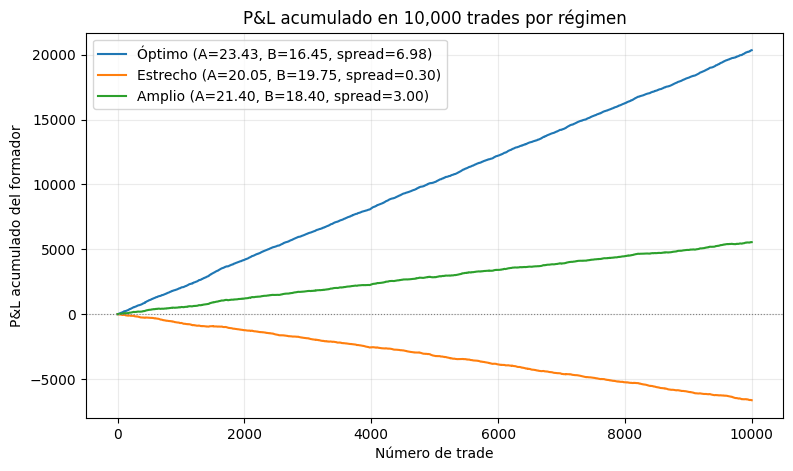

In [15]:
fig = figura_pnl_acumulado(sims, regs)
plt.show()

### Figura 3: inventario acumulado a lo largo de los 10,000 trades

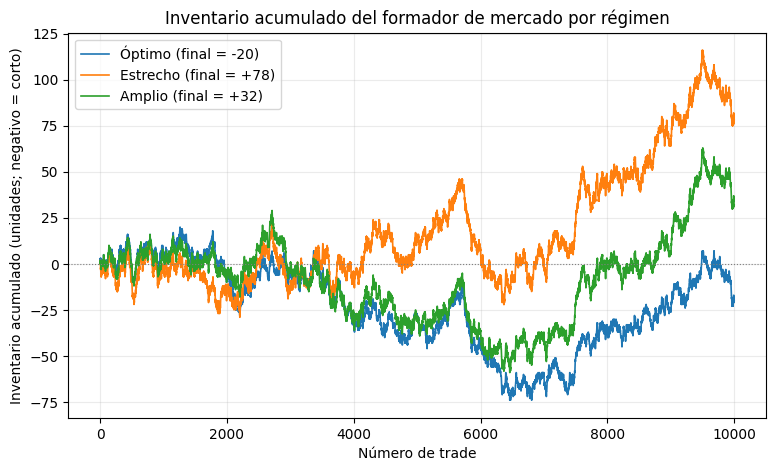

In [16]:
fig = figura_inventario(sims, regs)
plt.show()

### Figura 4: distribución del P&L final del Monte Carlo

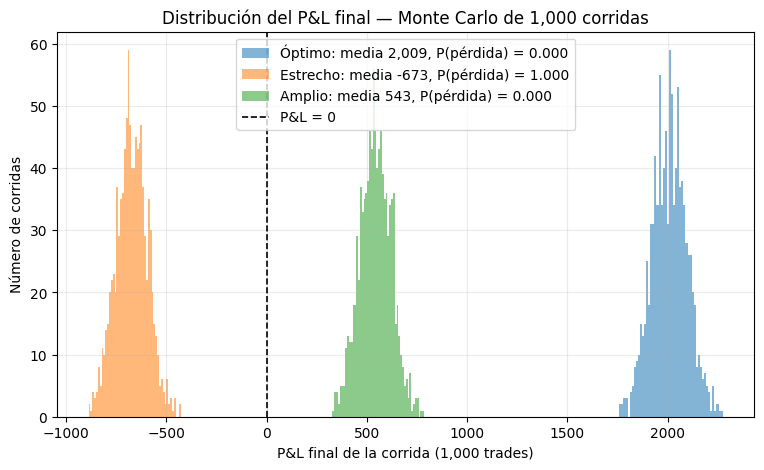

In [17]:
fig = figura_montecarlo(mc, N_TRADES_MC)
plt.show()

## 3.5 Análisis de sensibilidad a $\pi_I$

Se repite la optimización para $\pi_I \in \{0.1,\ 0.4,\ 0.7\}$, manteniendo $\pi_L = 1 - \pi_I$.

In [18]:
sensibilidad = tabla_sensibilidad(p=p)
sensibilidad.round(4)

,Ask,Bid,Spread,Utilidad esperada
pi_I,,,,
0.1000,23.1065,16.7088,6.3977,1.3787
0.4000,23.4277,16.4517,6.9760,0.8403
0.7000,24.0008,16.0070,7.9937,0.3366


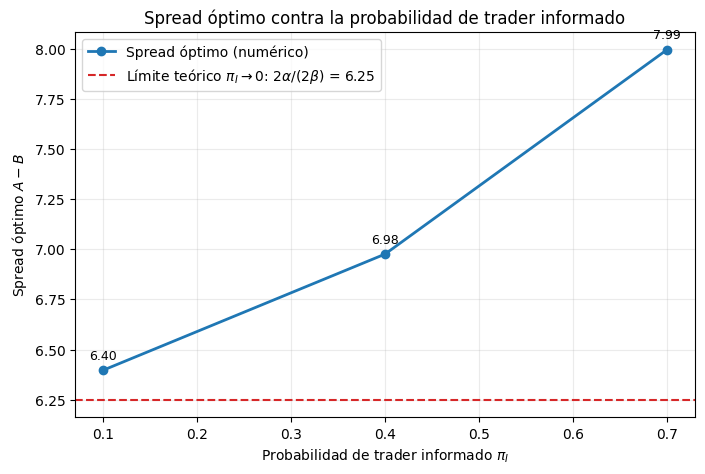

In [19]:
fig = figura_sensibilidad(sensibilidad, p)
plt.show()

**Contraste con la teoría.** El spread es creciente en $\pi_I$: entre más probable es que quien
llega esté informado, más caro sale cotizar cerca de $S_0$ y más se abre el formador. La utilidad
esperada, en cambio, cae de 1.38 a 0.34, porque ampliar el spread es una defensa y no un negocio.

El contraste cuantitativo es el caso límite $\pi_I \to 0$, donde el problema se reduce al del
monopolista y el spread total teórico es $2\alpha/(2\beta) = 6.25$. Con $\pi_I = 0.1$ el
optimizador da 6.40, apenas por encima, y con $\pi_I = 0$ exactamente 6.25 (es una de las pruebas
de `tests/test_model.py`). La curva sale del valor teórico correcto.

---

Las cinco preguntas de análisis están respondidas con estas mismas cifras en el `README.md`.